# Regression and uncertainty

**How do you fit a model to data, and how much should you believe the answer?**

Almost every number in seismology is estimated by fitting a model to data: a magnitude, a
velocity, the location of an earthquake. This session builds the standard way of fitting, least
squares, and then the part that is easy to skip and costly to get wrong: saying how uncertain the
answer is.

**The session answers four questions.**

1. How does least squares fit a model, and why is it the right fit when the errors are Gaussian?
   (A.1–A.2)
2. Where does an error bar come from, does a 95 % interval really contain the truth 95 % of the time,
   and which interval does a prediction need? (A.3–A.4)
3. What happens when columns move together, and what does a prior on the coefficients buy? (A.5–A.6)
4. What changes when the data are not Gaussian, and what is the *b*-value of The Geysers? (A.7, Part B)

**Part A** teaches the ideas on **synthetic data**, generated from known values, so that every
estimate and every error bar can be checked against the value that produced it. No real dataset
allows that check. **Part B** applies them to the Geysers earthquake catalogue, where the truth is
unknown, and shows what can be checked instead.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(207)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})
print("seed 207: every number below is reproducible")


seed 207: every number below is reproducible


## Part A · Regression and uncertainty, on synthetic data

### A.1 · A seismological regression

An earthquake shakes the ground, and a seismometer at distance $R$ from it records a peak amplitude
$A$. Larger earthquakes give larger amplitudes. Amplitude falls with distance for two reasons: the
wave's energy spreads over a growing wavefront (**geometric spreading**), and part of it turns to
heat as it travels (**anelastic attenuation**).

Richter (1935) used this to define earthquake **magnitude**: the logarithm of the peak amplitude a
standard seismometer would record 100 km from the earthquake. A reading taken at any other
distance is corrected to 100 km, so a magnitude is a log amplitude plus a distance correction.
Turned around, the log amplitude is the magnitude minus that correction. As a model of the amplitude
$A$ (in millimetres on that standard instrument), with the correction written out:

$$\log_{10} A = c_0 + c_1 M + c_2 \log_{10} R + c_3 R + \varepsilon .$$

- $c_1 M$: a larger magnitude gives a larger amplitude.
- $c_2 \log_{10} R$: spreading makes the amplitude fall as a power of distance.
- $c_3 R$: attenuation makes it fall exponentially with distance, which is linear in $\log_{10} A$.
- $\varepsilon$: the scatter of a single reading about the relation.

Hutton & Boore (1987) fitted the distance correction for southern California from 7,355 amplitudes
of 814 earthquakes, with $R$ the distance to the earthquake's source at depth. Their correction,
together with $c_1 = 1$ (which is what makes $M$ a magnitude), fixes all four coefficients. We take
those values as the **truth**, generate readings from them with a scatter we choose, 0.3 in
$\log_{10} A$, and then pretend not to know the values.


In [2]:
# The truth: Hutton & Boore's (1987) southern-California coefficients, written for the columns above.
BETA_TRUE = np.array([-0.591, 1.000, -1.110, -0.00189])      # c0, c1, c2, c3
SIGMA_TRUE = 0.30                                              # scatter of one reading, in log10 A
NAMES = ["c0", "c1 (M)", "c2 (log10 R)", "c3 (R)"]

n = 2000
M = rng.uniform(1.0, 4.5, n)                                   # magnitudes
R = 10 ** rng.uniform(np.log10(5), np.log10(300), n)           # distances 5-300 km, even in log R
logA = (BETA_TRUE[0] + BETA_TRUE[1] * M + BETA_TRUE[2] * np.log10(R) + BETA_TRUE[3] * R
        + rng.normal(0, SIGMA_TRUE, n))
print(f"{n} readings: M {M.min():.1f} to {M.max():.1f}, R {R.min():.0f} to {R.max():.0f} km")


2000 readings: M 1.0 to 4.5, R 5 to 300 km


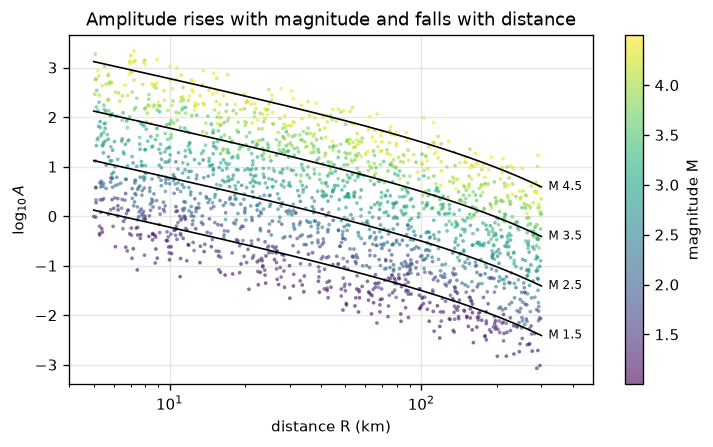

In [3]:
def true_logA(m, r):
    return BETA_TRUE[0] + BETA_TRUE[1] * m + BETA_TRUE[2] * np.log10(r) + BETA_TRUE[3] * r


fig, ax = plt.subplots(figsize=(6.2, 3.8))
points = ax.scatter(R, logA, c=M, s=5, cmap="viridis", alpha=0.6, linewidths=0)
r_line = np.logspace(np.log10(5), np.log10(300), 200)
for m in (1.5, 2.5, 3.5, 4.5):
    ax.plot(r_line, true_logA(m, r_line), "k-", lw=1)
    ax.text(320, true_logA(m, 300), f"M {m}", fontsize=7, va="center")
ax.set_xscale("log")
ax.set_xlim(4, 480)
ax.set(xlabel="distance R (km)", ylabel=r"$\log_{10} A$",
       title="Amplitude rises with magnitude and falls with distance")
fig.colorbar(points, ax=ax, label="magnitude M")
fig.tight_layout()
plt.show()


The black lines are the truth; the dots scatter about them by 0.3 in $\log_{10} A$.

The relation is not a straight line in $R$, yet it is a **linear model**, because each coefficient
multiplies a known quantity. Write one row per reading and stack the rows:

$$y = X\beta + \varepsilon, \qquad
y = \begin{bmatrix}\log_{10}A_1\\ \vdots\\ \log_{10}A_n\end{bmatrix},\quad
X = \begin{bmatrix} 1 & M_1 & \log_{10}R_1 & R_1 \\ \vdots & \vdots & \vdots & \vdots \\
1 & M_n & \log_{10}R_n & R_n \end{bmatrix},\quad
\beta = \begin{bmatrix} c_0\\ c_1\\ c_2\\ c_3\end{bmatrix}.$$

$X$ is the **design matrix**: one row per measurement, one column per parameter. Its columns can be
any functions of what was measured, and choosing them is where the physics goes. The linear
inversions later in the course have exactly this form.


### A.2 · Least squares, and why it is maximum likelihood

#### The least-squares solution

Choose $\beta$ to make the **residuals** $y - X\beta$ small, measured by their sum of squares
$S(\beta) = \lVert y - X\beta\rVert^2$. A hat marks an estimate: $\hat\beta$ is computed from the
data, $\beta$ is the unknown truth.

1. Expand: $S(\beta) = y^\top y - 2\beta^\top X^\top y + \beta^\top X^\top X\beta$.
2. Differentiate: $\partial S/\partial\beta = -2X^\top y + 2X^\top X\beta$. This uses two rules of matrix
   calculus: $\partial(\beta^\top a)/\partial\beta = a$ for a vector $a$, and
   $\partial(\beta^\top A\beta)/\partial\beta = 2A\beta$ for a symmetric matrix $A$, here $A = X^\top X$.
3. Set the derivative to zero. This gives the **normal equations**, $X^\top X\,\hat\beta = X^\top y$,
   so $\hat\beta = (X^\top X)^{-1}X^\top y$. The second derivative is $2X^\top X$, and
   $v^\top X^\top X v = \lVert Xv\rVert^2 \ge 0$ for every direction $v$, so $S$ is a bowl and this
   is its minimum.
4. Rearranged, step 3 says $X^\top(y - X\hat\beta) = 0$: the residual is **orthogonal to every
   column of $X$**. What is left over is the part of the data the columns cannot represent.

**Exercise 1.** Build the design matrix `X` from `M` and `R`, with the columns in the order above,
and solve the normal equations for `beta_normal` using `np.linalg.solve`. The cell after it compares
your answer with NumPy's least-squares solver and with the truth.


In [4]:
X = np.column_stack([np.ones(n), M, np.log10(R), R])
beta_normal = np.linalg.solve(X.T @ X, X.T @ logA)


In [5]:
# Check Exercise 1. The rest of the notebook continues from NumPy's solver, which gives the same answer
# without forming X^T X. Forming it squares the condition number of X (A.5), which loses precision when
# columns are nearly collinear.
X = np.column_stack([np.ones(n), M, np.log10(R), R])
y = logA
beta_hat = np.linalg.lstsq(X, y, rcond=None)[0]
if "beta_normal" not in globals():
    print("Exercise 1 has not stored beta_normal yet; continuing with np.linalg.lstsq\n")
else:
    assert np.shape(beta_normal) == (4,), "beta_normal needs one value per column: c0, c1, c2, c3"
    assert np.allclose(beta_normal, beta_hat, rtol=1e-6, atol=1e-9), \
        "the answers differ: does X have the columns 1, M, log10 R, R, in that order?"

resid = y - X @ beta_hat
print(f"{'':>13s} {'estimate':>9s} {'truth':>9s}")
for name, b, t in zip(NAMES, beta_hat, BETA_TRUE):
    print(f"{name:>13s} {b:9.5f} {t:9.5f}")
print(f"\nlargest |X^T (y - X beta_hat)| = {np.abs(X.T @ resid).max():.1e}   (zero, up to rounding)")


               estimate     truth
           c0  -0.56158  -0.59100
       c1 (M)   0.99187   1.00000
 c2 (log10 R)  -1.11627  -1.11000
       c3 (R)  -0.00183  -0.00189

largest |X^T (y - X beta_hat)| = 9.2e-09   (zero, up to rounding)


#### $R^2$, and what it does not say

The size of the residuals depends on the units of $y$, so a fit is usually summarised by

$$R^2 = 1 - \frac{\sum_i (y_i - x_i^\top\hat\beta)^2}{\sum_i (y_i - \bar y)^2}.$$

The denominator is the residual sum of squares of the model with no predictors, which predicts the
mean $\bar y$ for every reading. $R^2$ is therefore the fraction of the scatter in $y$ that the
columns of $X$ account for, between 0 and 1 for any model with an intercept. It is the most reported
number in regression, and three things it does not say are worth knowing.

- **It cannot fall when a column is added.** By step 4, least squares projects $y$ onto the columns
  of $X$. Another column can only enlarge that space, so the residual can only shrink, even when the
  new column is pure noise.
- **It is not an error bar.** It measures how much scatter the fit removed, not how well any one
  coefficient is determined; A.5 shows a fit with a high $R^2$ whose coefficients trade off.
- **It does not say the model is right.** It compares the fit only with predicting the mean.

**Adjusted $R^2$**, $1 - (1 - R^2)(n - 1)/(n - k - 1)$ for $k$ predictors besides the intercept,
charges for each column. The next cell adds columns of pure noise, which carry nothing because we
drew them, to all 2,000 readings and to the first 60.


In [6]:
def r_squared(X_m, y_m):
    b = np.linalg.lstsq(X_m, y_m, rcond=None)[0]
    r = y_m - X_m @ b
    return 1 - (r @ r) / np.sum((y_m - y_m.mean()) ** 2)


def adjusted(r2, size, k):
    return 1 - (1 - r2) * (size - 1) / (size - k - 1)


junk = np.random.default_rng(3)
print(f"{'readings':>9s} {'noise columns':>14s} {'R^2':>7s} {'adjusted':>9s}")
for size in (2000, 60):
    for extra in (0, 5, 20):
        X_k = np.column_stack([X[:size], junk.normal(size=(size, extra))])
        r2 = r_squared(X_k, y[:size])
        print(f"{size:9d} {extra:14d} {r2:7.4f} {adjusted(r2, size, 3 + extra):9.4f}")


 readings  noise columns     R^2  adjusted
     2000              0  0.9446    0.9445
     2000              5  0.9447    0.9444
     2000             20  0.9456    0.9449
       60              0  0.9427    0.9396
       60              5  0.9470    0.9387
       60             20  0.9564    0.9286


With 2,000 readings, twenty columns of noise change $R^2$ only in the third decimal. With 60 readings they
raise it from 0.943 to 0.956, while adjusted $R^2$ falls from 0.940 to 0.929. Neither number says the
columns were noise; that is known only because we made them. With few data, extra columns fit the
noise in those particular data; Sep 15 calls this overfitting and returns to it.


#### Why squares? Least squares is maximum likelihood

Nothing so far said why the residuals are squared rather than, say, taken as absolute values.
Probability does. Suppose each reading's error is an independent draw from a Gaussian with standard
deviation $\sigma$: $\varepsilon_i \sim N(0, \sigma^2)$. Write $x_i^\top$ for row $i$ of $X$.

1. The probability density of one reading is
   $p(y_i\mid\beta) = \dfrac{1}{\sqrt{2\pi}\,\sigma}\exp\!\left[-\dfrac{(y_i - x_i^\top\beta)^2}{2\sigma^2}\right]$.
2. The readings are independent, so the probability of all of them together, the **likelihood**,
   is the product $L(\beta) = \prod_i p(y_i\mid\beta)$.
3. Its logarithm turns the product into a sum:
   $\ell(\beta) = \log L(\beta) = -n\log\!\left(\sqrt{2\pi}\,\sigma\right) - \dfrac{S(\beta)}{2\sigma^2}$.
4. Only the last term depends on $\beta$, and it enters with a minus sign. **The $\beta$ that
   maximises the likelihood is the $\beta$ that minimises $S$.**

Least squares is the **maximum-likelihood estimate** for independent Gaussian errors. The argument
is a recipe that works for any kind of error, and this session uses it again in A.3, A.6 and A.7:

1. write down the likelihood of the data under the model;
2. maximise it to get the estimate;
3. read the uncertainty from how sharply the likelihood peaks (exactly for Gaussian errors, and
   approximately, improving with more data, for other kinds).

The figure shows the log-likelihood along $c_2$, the spreading coefficient, with the other
coefficients held at their estimates.


log-likelihood is largest at c2 = -1.1163; least squares gave -1.1163


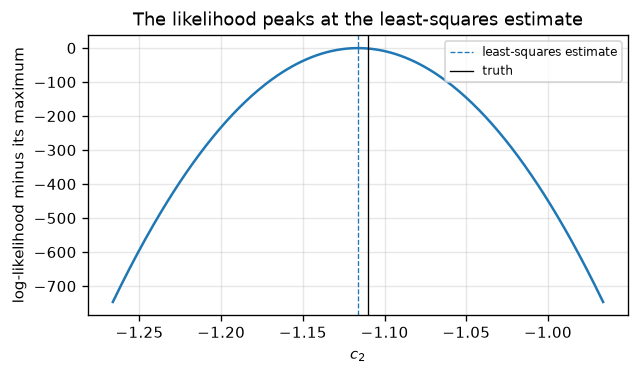

In [7]:
sigma_hat = np.sqrt(resid @ resid / (n - X.shape[1]))         # the scatter, estimated from the residuals (A.3)


def log_likelihood(beta):
    r = y - X @ beta
    return -n * np.log(np.sqrt(2 * np.pi) * sigma_hat) - (r @ r) / (2 * sigma_hat**2)


c2_grid = np.linspace(beta_hat[2] - 0.15, beta_hat[2] + 0.15, 301)
ll = np.array([log_likelihood(np.r_[beta_hat[:2], c2, beta_hat[3]]) for c2 in c2_grid])
print(f"log-likelihood is largest at c2 = {c2_grid[ll.argmax()]:.4f}; least squares gave {beta_hat[2]:.4f}")

fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.plot(c2_grid, ll - ll.max(), "C0-")
ax.axvline(beta_hat[2], color="C0", lw=0.8, ls="--", label="least-squares estimate")
ax.axvline(BETA_TRUE[2], color="k", lw=0.8, label="truth")
ax.set(xlabel=r"$c_2$", ylabel="log-likelihood minus its maximum",
       title="The likelihood peaks at the least-squares estimate")
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()


The curve is a parabola, because $S(\beta)$ is quadratic in $\beta$, and its peak is the least-squares
estimate. How sharply it peaks decides the error bar.

The estimates in the table of Exercise 1 were close to the truth but not equal to it: the scatter in the
readings leaves its mark on the estimates. How close they should be expected to be is the question of A.3.


### A.3 · Where the error bar comes from

The estimates depend on the particular errors in these 2,000 readings. Another set of readings at the
same magnitudes and distances would give slightly different estimates, so $\hat\beta$ is itself a random
quantity, and its spread is the uncertainty. For several estimates at once that spread is a
**covariance matrix**: entry $(j, j)$ is the variance of $\hat\beta_j$, the square of its
**standard error**, and entry $(j, k)$ says how $\hat\beta_j$ and $\hat\beta_k$ vary together.

1. Substitute $y = X\beta + \varepsilon$ into the estimator:
   $\hat\beta = (X^\top X)^{-1}X^\top(X\beta + \varepsilon) = \beta + (X^\top X)^{-1}X^\top\varepsilon$.
2. The errors average to zero, so on average $\hat\beta = \beta$: least squares is **unbiased**.
3. The spread comes from the second term. For independent errors of variance $\sigma^2$,
   $\mathrm{Cov}(\varepsilon) = \sigma^2 I$ ($I$ is the identity matrix), and
   $\mathrm{Cov}(\hat\beta) = (X^\top X)^{-1}X^\top(\sigma^2 I)\,X(X^\top X)^{-1} = \sigma^2(X^\top X)^{-1}$.
4. $\sigma$ is unknown, so estimate it from the residuals,
   $\hat\sigma^2 = \lVert y - X\hat\beta\rVert^2/(n - p)$ with $p = 4$ parameters. Dividing by
   $n - p$ rather than $n$ allows for the $p$ directions the fit has already used.

The standard error of $\hat\beta_j$ is the square root of entry $(j, j)$ of
$\hat\sigma^2(X^\top X)^{-1}$, and $\hat\beta_j \pm 1.96$ standard errors is its **95 % interval**.
(Because $\sigma$ was estimated, the exact multiplier is a quantile of Student's $t$ distribution
with $n - p$ degrees of freedom; the next cell prints it, and with 2,000 readings it is 1.96.)

This is step 3 of the recipe in A.2. Differentiating the log-likelihood twice gives
$-\partial^2\ell/\partial\beta\,\partial\beta^\top = X^\top X/\sigma^2$, the curvature at the peak,
and the covariance is its inverse. **A sharply peaked likelihood is a small error bar.** For the Gaussian
linear model this is exact. For other likelihoods, such as the one in A.7, the inverse curvature gives
the error bar approximately, and the approximation improves as the number of data grows.


In [8]:
from scipy import stats

cov = sigma_hat**2 * np.linalg.inv(X.T @ X)
se = np.sqrt(np.diag(cov))
print(f"sigma_hat = {sigma_hat:.3f}   (truth {SIGMA_TRUE})")
print(f"95 % multiplier from Student's t with n - p = {n - 4} degrees of freedom: {stats.t.ppf(0.975, n - 4):.3f}\n")
print(f"{'':>13s} {'estimate':>9s} {'std error':>10s} {'truth':>9s} {'(estimate - truth) / se':>24s}")
for name, b, s, t in zip(NAMES, beta_hat, se, BETA_TRUE):
    print(f"{name:>13s} {b:9.5f} {s:10.5f} {t:9.5f} {(b - t) / s:24.2f}")


sigma_hat = 0.296   (truth 0.3)
95 % multiplier from Student's t with n - p = 1996 degrees of freedom: 1.961

               estimate  std error     truth  (estimate - truth) / se
           c0  -0.56158    0.03925  -0.59100                     0.75
       c1 (M)   0.99187    0.00649   1.00000                    -1.25
 c2 (log10 R)  -1.11627    0.02870  -1.11000                    -0.22
       c3 (R)  -0.00183    0.00019  -0.00189                     0.30


Every estimate lies within two standard errors of the truth. That is what the error bars
promise, but one experiment is not a test.

**An error bar is a claim about repeated experiments**: if the experiment were repeated many times,
the 95 % interval would contain the truth in 95 % of them. Real data never allow the repetition.
Synthetic data do.

**Exercise 2.** Repeat the experiment 1,000 times with a fresh generator
`np.random.default_rng(1)`. Keep the same design matrix `X`, draw new errors, refit, compute each
coefficient's standard error from that repetition's own residuals, and count how often
$\hat\beta_j \pm 1.96\,\mathrm{se}_j$ contains the truth. Store the four counts in `covered`, the
number of repetitions in `n_repeats`, and the 1,000 estimates of $c_2$ in `c2_estimates`.


In [9]:
n_repeats = 1000
rep = np.random.default_rng(1)
XtX_inv = np.linalg.inv(X.T @ X)
covered = np.zeros(4)
c2_estimates = []
for _ in range(n_repeats):
    y_k = X @ BETA_TRUE + rep.normal(0, SIGMA_TRUE, n)
    b_k = XtX_inv @ X.T @ y_k
    r_k = y_k - X @ b_k
    se_k = np.sqrt(np.diag((r_k @ r_k) / (n - 4) * XtX_inv))
    covered += np.abs(b_k - BETA_TRUE) < 1.96 * se_k
    c2_estimates.append(b_k[2])


In [10]:
# Check Exercise 2
if "covered" not in globals() or "n_repeats" not in globals() or "c2_estimates" not in globals():
    print("Exercise 2 has not stored covered, n_repeats and c2_estimates yet")
else:
    assert len(c2_estimates) == n_repeats, "c2_estimates needs one estimate of c2 per repetition"
    fraction = np.asarray(covered) / n_repeats
    for name, f in zip(NAMES, fraction):
        print(f"{name:>13s}: the 95 % interval contained the truth in {100 * f:.1f} % of {n_repeats} repetitions")
    assert np.all((fraction > 0.92) & (fraction < 0.98)), \
        "is each interval 1.96 standard errors wide, with the standard error from that repetition's residuals?"


           c0: the 95 % interval contained the truth in 95.0 % of 1000 repetitions
       c1 (M): the 95 % interval contained the truth in 94.9 % of 1000 repetitions
 c2 (log10 R): the 95 % interval contained the truth in 95.3 % of 1000 repetitions
       c3 (R): the 95 % interval contained the truth in 95.8 % of 1000 repetitions


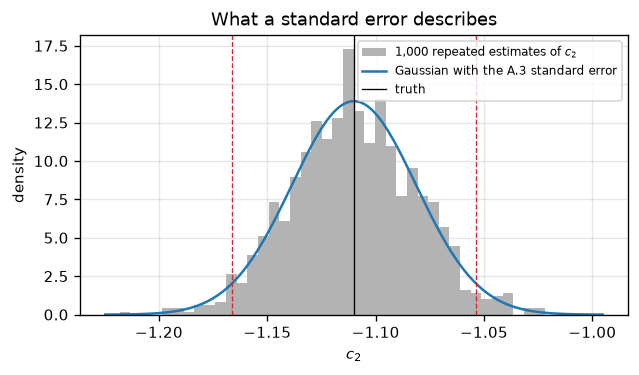

standard deviation of the 1,000 estimates: 0.0288; standard error from one fit: 0.0287
estimates within the dashed lines: 95.1 %


In [11]:
# The spread that the error bar describes: the 1,000 estimates of c2 against the Gaussian the standard error predicts
if "c2_estimates" not in globals():
    print("Exercise 2 has not stored c2_estimates yet")
else:
    fig, ax = plt.subplots(figsize=(5.4, 3.2))
    ax.hist(c2_estimates, bins=40, density=True, color="0.7", label="1,000 repeated estimates of $c_2$")
    grid = np.linspace(BETA_TRUE[2] - 4 * se[2], BETA_TRUE[2] + 4 * se[2], 200)
    ax.plot(grid, stats.norm.pdf(grid, BETA_TRUE[2], se[2]), "C0-", label="Gaussian with the A.3 standard error")
    for edge in (-1.96, 1.96):
        ax.axvline(BETA_TRUE[2] + edge * se[2], color="C3", lw=0.8, ls="--")
    ax.axvline(BETA_TRUE[2], color="k", lw=0.8, label="truth")
    ax.set(xlabel=r"$c_2$", ylabel="density", title="What a standard error describes")
    ax.legend(fontsize=7)
    fig.tight_layout()
    plt.show()
    print(f"standard deviation of the 1,000 estimates: {np.std(c2_estimates):.4f}; standard error from one fit: {se[2]:.4f}")
    inside_band = np.mean(np.abs(np.asarray(c2_estimates) - BETA_TRUE[2]) < 1.96 * se[2])
    print(f"estimates within the dashed lines: {100 * inside_band:.1f} %")


The histogram is what the error bar describes: estimates scattered about the truth with a standard
deviation equal to the standard error of one fit, and 95 % of them within the dashed lines.

Each interval contains the truth about 95 % of the time, as promised. The promise holds here because
the errors really are independent and Gaussian, which is what steps 3 and 4 assumed. A.7 meets
data for which a common interval breaks its promise badly.


### A.4 · Predicting the next reading: two intervals

A fitted relation is used in two ways, and each needs its own interval.

**Where is the curve?** The fitted value at a new row $x_0$ (a magnitude and a distance) is
$x_0^\top\hat\beta$. It combines the estimates linearly, so its variance follows from A.3:
$\mathrm{Var}(x_0^\top\hat\beta) = x_0^\top\,\mathrm{Cov}(\hat\beta)\,x_0 = \sigma^2\,x_0^\top(X^\top X)^{-1}x_0$.
More readings pin the curve down, and this variance shrinks towards zero. It gives the
**confidence interval**.

**What will the next station read?** A new reading is $y_0 = x_0^\top\beta + \varepsilon_0$, with an
error of its own. The prediction error has two independent parts, the error in the curve and the
new reading's scatter, so their variances add:

$$\mathrm{Var}(y_0 - x_0^\top\hat\beta) = \underbrace{\sigma^2\,x_0^\top(X^\top X)^{-1}x_0}_{\text{where the curve is}}
+ \underbrace{\sigma^2}_{\text{scatter of one reading}} .$$

The second term does not depend on how many readings were fitted. No amount of data removes it,
because it is the scatter of the thing being predicted. This variance gives the **prediction
interval**.


In [12]:
x0 = np.array([1.0, 3.0, np.log10(50.0), 50.0])          # a magnitude 3 earthquake at 50 km
half_ci = 1.96 * np.sqrt(x0 @ cov @ x0)
half_pi = 1.96 * np.sqrt(x0 @ cov @ x0 + sigma_hat**2)
print(f"M 3 at 50 km: fitted log10 A = {x0 @ beta_hat:.3f}")
print(f"  95 % confidence interval   +/- {half_ci:.3f}")
print(f"  95 % prediction interval   +/- {half_pi:.3f}   ({half_pi / half_ci:.0f} times wider)")


M 3 at 50 km: fitted log10 A = 0.426
  95 % confidence interval   +/- 0.019
  95 % prediction interval   +/- 0.580   (30 times wider)


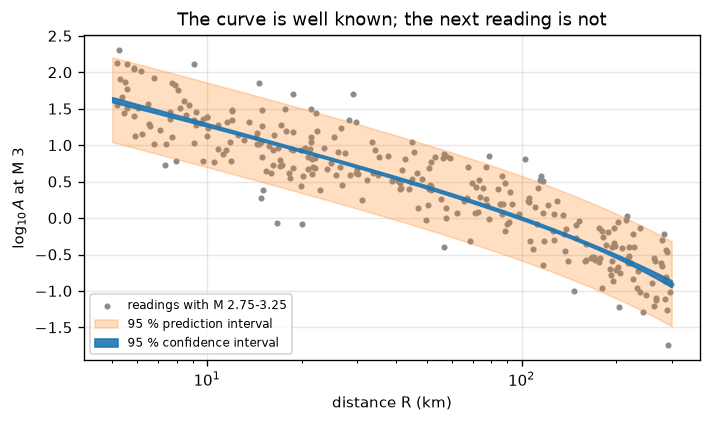

In [13]:
r_line = np.logspace(np.log10(5), np.log10(300), 200)
X_line = np.column_stack([np.ones_like(r_line), np.full_like(r_line, 3.0), np.log10(r_line), r_line])
fit = X_line @ beta_hat
var_curve = np.einsum("ij,jk,ik->i", X_line, cov, X_line)
near_m3 = np.abs(M - 3.0) < 0.25

fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.scatter(R[near_m3], y[near_m3], s=7, color="0.55", label="readings with M 2.75-3.25")
ax.fill_between(r_line, fit - 1.96 * np.sqrt(var_curve + sigma_hat**2), fit + 1.96 * np.sqrt(var_curve + sigma_hat**2),
                color="C1", alpha=0.25, label="95 % prediction interval")
ax.fill_between(r_line, fit - 1.96 * np.sqrt(var_curve), fit + 1.96 * np.sqrt(var_curve),
                color="C0", alpha=0.9, label="95 % confidence interval")
ax.set_xscale("log")
ax.set(xlabel="distance R (km)", ylabel=r"$\log_{10} A$ at M 3",
       title="The curve is well known; the next reading is not")
ax.legend(fontsize=7, loc="lower left")
fig.tight_layout()
plt.show()


The dark band, where the curve is, is so narrow at 2,000 readings that it looks like a line. The
pale band is where the next reading will fall. The next cell repeats the fit for networks of
different sizes and follows both half-widths at M 3 and 50 km.


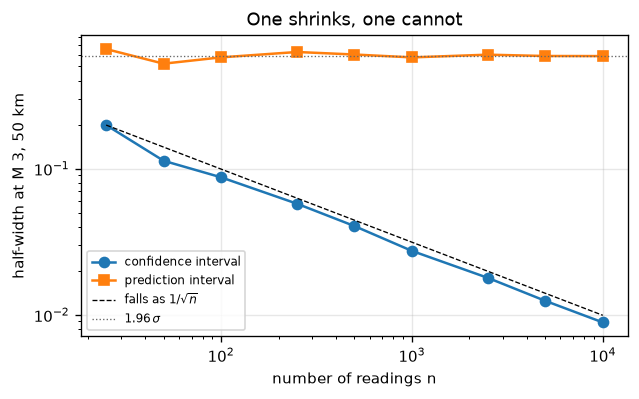

n =    25: confidence +/- 0.198, prediction +/- 0.656
n =   500: confidence +/- 0.040, prediction +/- 0.603
n = 10000: confidence +/- 0.009, prediction +/- 0.588


In [14]:
sizes = [25, 50, 100, 250, 500, 1000, 2500, 5000, 10000]
widths = []
for size in sizes:
    rng_n = np.random.default_rng(size)
    m_s = rng_n.uniform(1.0, 4.5, size)
    r_s = 10 ** rng_n.uniform(np.log10(5), np.log10(300), size)
    X_s = np.column_stack([np.ones(size), m_s, np.log10(r_s), r_s])
    y_s = X_s @ BETA_TRUE + rng_n.normal(0, SIGMA_TRUE, size)
    b_s = np.linalg.lstsq(X_s, y_s, rcond=None)[0]
    s2 = np.sum((y_s - X_s @ b_s) ** 2) / (size - 4)
    v = s2 * x0 @ np.linalg.inv(X_s.T @ X_s) @ x0
    t = stats.t.ppf(0.975, size - 4)                      # Student's t: noticeably above 1.96 for small n
    widths.append((t * np.sqrt(v), t * np.sqrt(v + s2)))
widths = np.array(widths)

fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.loglog(sizes, widths[:, 0], "o-", label="confidence interval")
ax.loglog(sizes, widths[:, 1], "s-", label="prediction interval")
ax.loglog(sizes, widths[0, 0] * np.sqrt(sizes[0] / np.array(sizes)), "k--", lw=0.8, label=r"falls as $1/\sqrt{n}$")
ax.axhline(1.96 * SIGMA_TRUE, color="0.4", lw=0.8, ls=":", label=r"$1.96\,\sigma$")
ax.set(xlabel="number of readings n", ylabel="half-width at M 3, 50 km", title="One shrinks, one cannot")
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()
for size, (c_w, p_w) in zip(sizes[::4], widths[::4]):
    print(f"n = {size:5d}: confidence +/- {c_w:.3f}, prediction +/- {p_w:.3f}")


The confidence half-width falls as $1/\sqrt n$, from 0.198 with 25 readings to 0.009 with 10,000. The
prediction half-width stays near $1.96\,\sigma$ at every size. It is a little wider with 25 readings,
where the curve itself is still uncertain and Student's $t$ is larger than 1.96.

**Exercise 3.** Before running anything, predict: if you fit the relation and then record one new
reading at M 3 and 50 km, how often will it fall inside the 95 % confidence interval, and how often
inside the 95 % prediction interval?

Then test it. Using `np.random.default_rng(2)`, repeat 2,000 times: draw new errors for all
readings, refit, draw one new reading at `x0` from the truth, and record whether it falls inside
each interval. Store the two fractions, between 0 and 1, in `inside_ci` and `inside_pi`.


In [15]:
rep = np.random.default_rng(2)
XtX_inv = np.linalg.inv(X.T @ X)
hits_ci = hits_pi = 0
for _ in range(2000):
    y_k = X @ BETA_TRUE + rep.normal(0, SIGMA_TRUE, n)
    b_k = XtX_inv @ X.T @ y_k
    s2_k = np.sum((y_k - X @ b_k) ** 2) / (n - 4)
    v_k = s2_k * x0 @ XtX_inv @ x0
    y_new = x0 @ BETA_TRUE + rep.normal(0, SIGMA_TRUE)
    hits_ci += abs(y_new - x0 @ b_k) < 1.96 * np.sqrt(v_k)
    hits_pi += abs(y_new - x0 @ b_k) < 1.96 * np.sqrt(v_k + s2_k)
inside_ci, inside_pi = hits_ci / 2000, hits_pi / 2000


In [16]:
# Check Exercise 3
if "inside_ci" not in globals() or "inside_pi" not in globals():
    print("Exercise 3 has not stored inside_ci and inside_pi yet")
else:
    print(f"new reading inside the confidence interval: {100 * inside_ci:.1f} %")
    print(f"new reading inside the prediction interval: {100 * inside_pi:.1f} %")
    assert 0 <= inside_ci <= 1 and 0 <= inside_pi <= 1, "store fractions between 0 and 1, not counts"
    assert 0.92 < inside_pi < 0.98 and inside_ci < 0.2, \
        "is y_new a fresh noisy reading at x0, and does the prediction interval add s2 to the curve's variance?"


new reading inside the confidence interval: 5.5 %
new reading inside the prediction interval: 94.8 %


The confidence interval almost never contains the next reading, and the prediction interval contains
it 95 % of the time. Quoting a confidence interval as the uncertainty of a prediction is a common
mistake, and it understates the uncertainty many times over.


### A.5 · Collinearity: a good fit with poorly determined coefficients

Every estimate so far came back close to the truth, with small error bars. That is a property of this
design, not of least squares. Over 5–300 km, $\log_{10}R$ and $R$ rise together, and when two columns
of $X$ move together, $X^\top X$ is close to singular and its inverse, the covariance of A.3, is large in
the direction that trades one coefficient against the other.

> The **combination** $c_2\log_{10}R + c_3R$ is well determined by the data. The **individual**
> coefficients $c_2$ and $c_3$ are much less so.

A published coefficient can then differ from yours by several standard errors while both curves pass
through the same data.


In [17]:
corr = cov / np.sqrt(np.outer(np.diag(cov), np.diag(cov)))          # the covariance, scaled to correlations
print(f"correlation of the columns log10 R and R:  {np.corrcoef(np.log10(R), R)[0, 1]:+.3f}")
print(f"correlation of the estimates c2 and c3:    {corr[2, 3]:+.3f}")
print(f"R^2 of the same fit:                       {r_squared(X, y):.3f}")


correlation of the columns log10 R and R:  +0.894
correlation of the estimates c2 and c3:    -0.894
R^2 of the same fit:                       0.945


#### Why correlated columns inflate a standard error

Take one column $x_j$, and call the matrix of all the other columns $X_{-j}$.

1. Regress $x_j$ on the other columns: $x_j = X_{-j}\gamma + z_j$. By step 4 of A.2 the residual $z_j$
   is orthogonal to every other column; it is the part of $x_j$ the other columns cannot reproduce.
2. Replacing $x_j$ by $z_j$ changes neither the fit nor the coefficient $\beta_j$, because
   $X\beta = X_{-j}(\beta_{-j} + \gamma\beta_j) + z_j\beta_j$.
3. Since $z_j$ is orthogonal to every column of $X_{-j}$, the matrix $X^\top X$ of the new design is zero
   everywhere except in two blocks, one for $X_{-j}$ and one for $z_j$. Its inverse splits the same way,
   so the entry of the inverse that belongs to $z_j$ is simply $1/\lVert z_j\rVert^2$.
4. By A.3, $\mathrm{Var}(\hat\beta_j) = \sigma^2/\lVert z_j\rVert^2$.
5. $\lVert z_j\rVert^2$ is the residual sum of squares of step 1, $(1 - R_j^2)\sum_i (x_{ij} - \bar x_j)^2$,
   where $R_j^2$ is the $R^2$ of that regression. So
   $$\mathrm{Var}(\hat\beta_j) = \frac{\sigma^2}{\sum_i (x_{ij} - \bar x_j)^2}\cdot\frac{1}{1 - R_j^2}.$$

The first factor is the variance the coefficient would have if its column were uncorrelated with the
others. The second is the **variance inflation factor**: how many times larger the variance is because
the other columns can predict this one.


In [18]:
for j in (1, 2, 3):
    others = np.delete(X, j, axis=1)
    z = X[:, j] - others @ np.linalg.lstsq(others, X[:, j], rcond=None)[0]      # step 1
    r2_j = 1 - (z @ z) / np.sum((X[:, j] - X[:, j].mean()) ** 2)
    print(f"{NAMES[j]:>13s}: sigma^2 / |z|^2 = {sigma_hat**2 / (z @ z):.3e}, covariance entry = {cov[j, j]:.3e}, "
          f"inflation factor = {1 / (1 - r2_j):.1f}")


       c1 (M): sigma^2 / |z|^2 = 4.210e-05, covariance entry = 4.210e-05, inflation factor = 1.0
 c2 (log10 R): sigma^2 / |z|^2 = 8.237e-04, covariance entry = 8.237e-04, inflation factor = 5.0
       c3 (R): sigma^2 / |z|^2 = 3.471e-08, covariance entry = 3.471e-08, inflation factor = 5.0


Both routes give the same variance. Magnitude is uncorrelated with distance in this design, so its
variance is not inflated. The variance of each distance coefficient is five times what it would be if
its column were uncorrelated with the other.

The 95 % confidence region for $c_2$ and $c_3$ together is an ellipse. For two coefficients at once its
boundary is not 1.96 standard errors in each direction. It is where the squared distance from the
estimate, measured with the inverse covariance, equals the 95 % point of the $\chi^2$ distribution with 2
degrees of freedom, which the next cell prints. The cell then takes the two ends of the ellipse's long
axis, and draws the attenuation curve that each implies.


95 % point of chi-squared with 2 degrees of freedom: 5.99
end A: c2 = -1.187, c3 = -0.00143
end B: c2 = -1.046, c3 = -0.00224
c2 differs between the ends by 4.9 standard errors; the two curves differ by at most 0.20 in log10 A (prediction half-width 0.58)


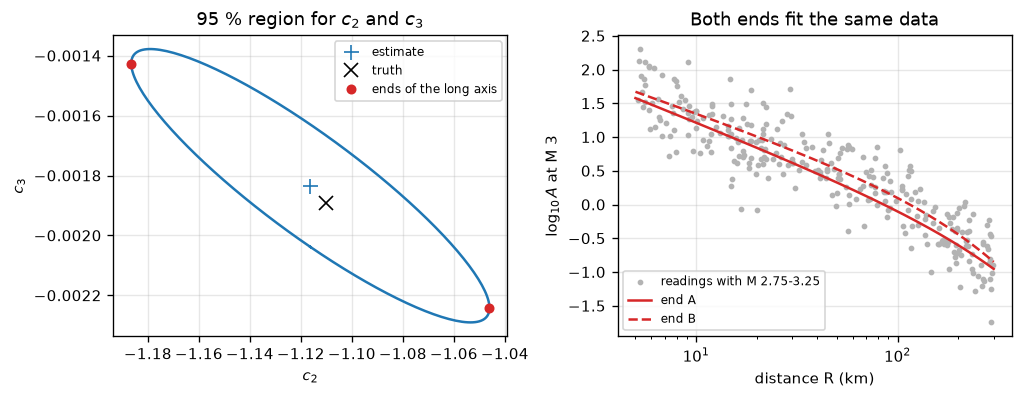

In [19]:
print(f"95 % point of chi-squared with 2 degrees of freedom: {stats.chi2.ppf(0.95, 2):.2f}")
w, V = np.linalg.eigh(cov[2:, 2:])
half_axis = V[:, -1] * np.sqrt(w[-1] * stats.chi2.ppf(0.95, 2))      # half the long axis of the 95 % ellipse
end_a, end_b = beta_hat[2:] + half_axis, beta_hat[2:] - half_axis
X_line = np.column_stack([np.ones_like(r_line), np.full_like(r_line, 3.0), np.log10(r_line), r_line])
curve_a = X_line @ np.r_[beta_hat[:2], end_a]
curve_b = X_line @ np.r_[beta_hat[:2], end_b]
print(f"end A: c2 = {end_a[0]:+.3f}, c3 = {end_a[1]:+.5f}")
print(f"end B: c2 = {end_b[0]:+.3f}, c3 = {end_b[1]:+.5f}")
print(f"c2 differs between the ends by {abs(end_a[0] - end_b[0]) / se[2]:.1f} standard errors; the two curves "
      f"differ by at most {np.abs(curve_a - curve_b).max():.2f} in log10 A (prediction half-width {half_pi:.2f})")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.6, 3.4))
theta = np.linspace(0, 2 * np.pi, 200)
ellipse = (V @ np.diag(np.sqrt(w * stats.chi2.ppf(0.95, 2))) @ np.vstack([np.cos(theta), np.sin(theta)])).T
a1.plot(beta_hat[2] + ellipse[:, 0], beta_hat[3] + ellipse[:, 1], "C0-")
a1.plot(*beta_hat[2:], "C0+", ms=9, label="estimate")
a1.plot(*BETA_TRUE[2:], "kx", ms=8, label="truth")
a1.plot([end_a[0], end_b[0]], [end_a[1], end_b[1]], "C3o", ms=5, label="ends of the long axis")
a1.set(xlabel=r"$c_2$", ylabel=r"$c_3$", title="95 % region for $c_2$ and $c_3$")
a1.legend(fontsize=7)
a2.scatter(R[near_m3], y[near_m3], s=6, color="0.7", label="readings with M 2.75-3.25")
a2.plot(r_line, curve_a, "C3-", label="end A")
a2.plot(r_line, curve_b, "C3--", label="end B")
a2.set_xscale("log")
a2.set(xlabel="distance R (km)", ylabel=r"$\log_{10} A$ at M 3", title="Both ends fit the same data")
a2.legend(fontsize=7, loc="lower left")
fig.tight_layout()
plt.show()


The two ends differ in $c_2$ by 4.9 standard errors, yet their curves differ by at most 0.20 in
$\log_{10} A$, about a third of the half-width of the prediction interval. Both are consistent with the
data, which pin down the curve far better than either coefficient.

Hutton & Boore (1987) write the distance terms centred at 100 km, as $\log_{10}(R/100)$ and $R - 100$,
and centring columns is standard advice for collinearity. Test it.


In [20]:
X_c = np.column_stack([np.ones(n), M, np.log10(R / 100), R - 100])
b_c = np.linalg.lstsq(X_c, y, rcond=None)[0]
r_c = y - X_c @ b_c
cov_c = (r_c @ r_c) / (n - 4) * np.linalg.inv(X_c.T @ X_c)
corr_c = cov_c / np.sqrt(np.outer(np.diag(cov_c), np.diag(cov_c)))
print(f"uncentred columns: correlation of c2 and c3 {corr[2, 3]:+.3f}, condition number of X {np.linalg.cond(X):6.1f}")
print(f"centred columns:   correlation of c2 and c3 {corr_c[2, 3]:+.3f}, condition number of X {np.linalg.cond(X_c):6.1f}")
print(f"residual sum of squares: {resid @ resid:.3f} uncentred, {r_c @ r_c:.3f} centred")


uncentred columns: correlation of c2 and c3 -0.894, condition number of X  789.4
centred columns:   correlation of c2 and c3 -0.894, condition number of X  375.7
residual sum of squares: 174.663 uncentred, 174.663 centred


Centring roughly halves the condition number, leaves the fit unchanged, and gives the intercept a
meaning: the log amplitude of a magnitude-0 earthquake at 100 km. The correlation between the two slopes
does not change at all. Shifting a column by a constant changes how it relates to the intercept, not how
two slopes trade against each other.

What the data do determine is a **direction** in the plane of $c_2$ and $c_3$: the short axis of the
ellipse. $c_3$ is a thousand times smaller than $c_2$, so the two are compared in units of their own
standard errors, which means finding the axes of their correlation matrix rather than of the covariance.


In [21]:
corr_23 = corr[2:, 2:]
axis_var, axes = np.linalg.eigh(corr_23)                          # eigenvalues in increasing order
for label, i in (("well determined", 0), ("poorly determined", 1)):
    u = axes[:, i] * np.sign(axes[0, i])
    print(f"{label:>17s}: {u[0]:+.2f} (c2 / se2) {u[1]:+.2f} (c3 / se3), standard deviation {np.sqrt(axis_var[i]):.2f}")
print(f"the data determine one direction {np.sqrt(axis_var[1] / axis_var[0]):.1f} times better than the other")


  well determined: +0.71 (c2 / se2) +0.71 (c3 / se3), standard deviation 0.33
poorly determined: +0.71 (c2 / se2) -0.71 (c3 / se3), standard deviation 1.38
the data determine one direction 4.2 times better than the other


In the well-determined direction, $c_2$ and $c_3$ move together, each by the same number of its own
standard errors. In the poorly determined direction, one rises as the other falls: that trade-off is
what their negative correlation means. There are three useful responses: report the well-determined
combination rather than either coefficient alone, drop one of the two terms, or add information about
the coefficients from outside the data, which is what A.6 does.


### A.6 · Ridge regression: a prior on the coefficients

When the data cannot pin some coefficients down, one response is to say beforehand how large they are
likely to be. Written as probability, that gives a widely used method.

1. **Likelihood.** As in A.2, $p(y\mid\beta) \propto \exp\!\left[-\lVert y - X\beta\rVert^2/2\sigma^2\right]$.
2. **Prior.** Before seeing the data, take $\beta \sim N(0, s^2 I)$, so
   $p(\beta) \propto \exp\!\left[-\lVert\beta\rVert^2/2s^2\right]$. The width $s$ is in the units of
   $\beta$: the size of coefficient that would not be surprising.
3. **Bayes' theorem.** The posterior is $p(\beta\mid y) \propto p(y\mid\beta)\,p(\beta)$. The normalising
   constant does not depend on $\beta$, so it does not move the maximum.
4. **Negative log.** $-\log p(\beta\mid y) = \dfrac{\lVert y - X\beta\rVert^2}{2\sigma^2} + \dfrac{\lVert\beta\rVert^2}{2s^2} + \text{const}$.
5. **Rescale** by $2\sigma^2$. The most probable $\beta$, the **maximum a posteriori (MAP)** estimate,
   minimises $\lVert y - X\beta\rVert^2 + \lambda\lVert\beta\rVert^2$ with $\lambda = \sigma^2/s^2$. This is
   **ridge regression**, and its penalty weight is the noise variance divided by the prior variance.
6. **Minimise.** Setting the derivative to zero gives $(X^\top X + \lambda I)\,\hat\beta_\lambda = X^\top y$.
   Adding $\lambda I$ raises every eigenvalue of $X^\top X$ by $\lambda$, so the system can be solved
   **even when $X^\top X$ is singular**. The inversions later in the course rely on this.
7. **What it does.** With the singular value decomposition $X = UDV^\top$,
   $\hat\beta_\lambda = \sum_i f_i\,\dfrac{u_i^\top y}{d_i}\,v_i$ with **filter factors**
   $f_i = d_i^2/(d_i^2 + \lambda)$. Directions the data constrain well ($d_i^2 \gg \lambda$) pass almost
   unchanged, and directions they barely constrain are shrunk towards zero.

The penalty treats every coefficient alike, but a coefficient's size depends on the units of its column.
Measure $R$ in metres instead of kilometres and $c_3$ becomes a thousand times smaller, so the penalty
would hardly touch it. The columns are therefore **standardised** first, each centred and divided by its
standard deviation, and the intercept is not penalised. The sum of the filter factors,
$\mathrm{df}(\lambda) = \sum_i f_i$, is the fit's **effective number of parameters**.


In [22]:
X_std = (X[:, 1:] - X[:, 1:].mean(axis=0)) / X[:, 1:].std(axis=0)      # M, log10 R, R: mean 0, sd 1
d = np.linalg.svd(X_std, compute_uv=False)
print(f"singular values of the standardised design: {np.round(d, 1)}\n")
print(f"{'lambda':>8s}  " + "  ".join(f"{'f' + str(i + 1):>5s}" for i in range(len(d))) + f"  {'df':>5s}")
for lam in (0.0, 1e1, 1e2, 1e3, 1e4):
    f = d**2 / (d**2 + lam)
    print(f"{lam:8.0e}  " + "  ".join(f"{v:5.3f}" for v in f) + f"  {f.sum():5.2f}")


singular values of the standardised design: [61.6 44.7 14.5]

  lambda     f1     f2     f3     df
   0e+00  1.000  1.000  1.000   3.00
   1e+01  0.997  0.995  0.955   2.95
   1e+02  0.974  0.952  0.679   2.61
   1e+03  0.791  0.666  0.175   1.63
   1e+04  0.275  0.166  0.021   0.46


The best-determined direction is shrunk least at every $\lambda$, and the weakest the most. With 2,000
readings and three slopes, though, every direction is well determined: even at $\lambda = 10$ all three
filter factors stay above 0.95, and a prior would only pull a good fit away from the data. A prior pays
when a model has many parameters, each resting on few data.

#### Where a prior pays: site terms

Some stations record systematically larger amplitudes than others, and Hutton & Boore (1987)
determined a correction for each station. In the model that is a **site term**: one extra coefficient
per station. With 60 stations the design has 64 columns, and with a few hundred readings each site term
rests on only a handful of them.

Here $\lambda = \sigma^2/s^2$ can be measured rather than tuned: $\sigma$ is the scatter of readings at one
station, and $s$ the spread of the site terms between stations. For this synthetic network we choose
$\sigma = 0.24$ and $s = 0.25$, in $\log_{10} A$.


In [23]:
SIGMA_W, S_SITE, N_STA = 0.24, 0.25, 60        # scatter at one station, spread of site terms, number of stations
LAM_SITE = SIGMA_W**2 / S_SITE**2


def site_design(rng_s, size):
    """The A.1 design plus one indicator column per station, for readings at randomly chosen stations."""
    m_s = rng_s.uniform(1.0, 4.5, size)
    r_s = 10 ** rng_s.uniform(np.log10(5), np.log10(300), size)
    D = np.zeros((size, N_STA))
    D[np.arange(size), rng_s.integers(0, N_STA, size)] = 1.0
    return np.column_stack([np.ones(size), m_s, np.log10(r_s), r_s, D])


def site_ridge(X_s, y_s, lam):
    """Ridge with the prior on the site terms only; the attenuation coefficients are not penalised."""
    penalty = np.zeros(X_s.shape[1])
    penalty[4:] = lam
    return np.linalg.solve(X_s.T @ X_s + np.diag(penalty), X_s.T @ y_s)


probe = site_design(np.random.default_rng(0), 250)
print(f"250 readings at 60 stations: {probe.shape[1]} columns, rank {np.linalg.matrix_rank(probe)}; "
      f"stations with no readings: {int((probe[:, 4:].sum(axis=0) == 0).sum())}")
print(f"lambda from the chosen scatters: sigma^2 / s^2 = {LAM_SITE:.2f}")


250 readings at 60 stations: 64 columns, rank 62; stations with no readings: 1
lambda from the chosen scatters: sigma^2 / s^2 = 0.92


The rank is below the number of columns: the 60 site columns add up to the intercept column, and a
station without readings has a column of zeros. $X^\top X$ is singular, so least squares has no unique
answer, and ridge has one (step 6).

The next cell simulates many such networks, fits ridge at a range of $\lambda$, and measures the error on
new readings at the same stations. Because the data are simulated, the true site terms are known.


  250 readings ( 4.2 per station): best lambda 1.00, error 0.0723 against 0.0770 at lambda = 0.01
  600 readings (10.0 per station): best lambda 1.00, error 0.0638 against 0.0644 at lambda = 0.01
 3000 readings (50.0 per station): best lambda 1.00, error 0.0587 against 0.0587 at lambda = 0.01


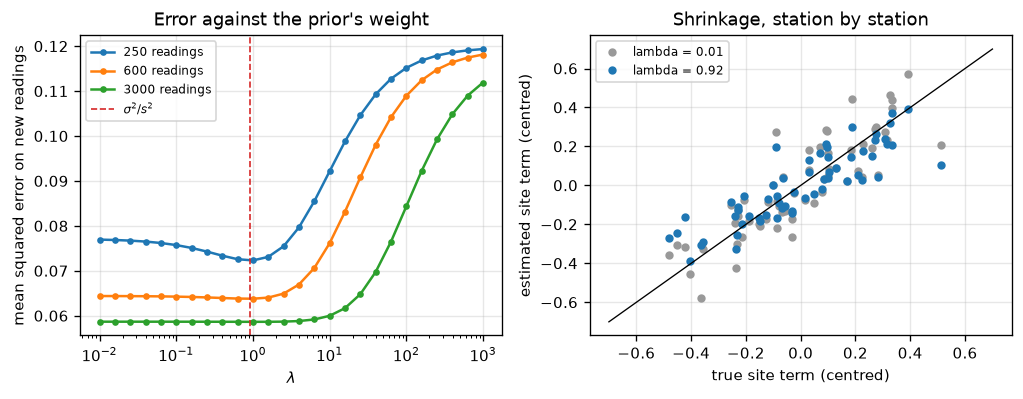

In [24]:
LAMS = np.logspace(-2, 3, 26)


def error_on_new_readings(size, trials=200, n_test=800):
    """Mean squared error on new readings at the same stations, averaged over simulated networks."""
    err = np.zeros(len(LAMS))
    for t in range(trials):
        rng_t = np.random.default_rng(7000 + t)
        truth = np.r_[BETA_TRUE, rng_t.normal(0, S_SITE, N_STA)]
        X_tr = site_design(rng_t, size)
        y_tr = X_tr @ truth + rng_t.normal(0, SIGMA_W, size)
        X_te = site_design(rng_t, n_test)
        y_te = X_te @ truth + rng_t.normal(0, SIGMA_W, n_test)
        for i, lam in enumerate(LAMS):
            err[i] += np.mean((y_te - X_te @ site_ridge(X_tr, y_tr, lam)) ** 2)
    return err / trials


curves = {size: error_on_new_readings(size) for size in (250, 600, 3000)}
for size, c in curves.items():
    best = int(c.argmin())
    print(f"{size:5d} readings ({size / N_STA:4.1f} per station): best lambda {LAMS[best]:.2f}, "
          f"error {c[best]:.4f} against {c[0]:.4f} at lambda = {LAMS[0]:.2f}")

rng_one = np.random.default_rng(7000)
site_true = rng_one.normal(0, S_SITE, N_STA)
X_one = site_design(rng_one, 250)
y_one = X_one @ np.r_[BETA_TRUE, site_true] + rng_one.normal(0, SIGMA_W, 250)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.6, 3.4))
for size, c in curves.items():
    a1.semilogx(LAMS, c, "o-", ms=3, label=f"{size} readings")
a1.axvline(LAM_SITE, color="C3", ls="--", lw=1, label=r"$\sigma^2/s^2$")
a1.set(xlabel=r"$\lambda$", ylabel="mean squared error on new readings", title="Error against the prior's weight")
a1.legend(fontsize=7)
for lam, colour in ((LAMS[0], "0.6"), (LAM_SITE, "C0")):
    est = site_ridge(X_one, y_one, lam)[4:]
    a2.plot(site_true - site_true.mean(), est - est.mean(), "o", ms=4, color=colour, label=f"lambda = {lam:.2f}")
a2.plot([-0.7, 0.7], [-0.7, 0.7], "k-", lw=0.8)
a2.set(xlabel="true site term (centred)", ylabel="estimated site term (centred)", title="Shrinkage, station by station")
a2.legend(fontsize=7)
fig.tight_layout()
plt.show()


With about four readings per station, the best $\lambda$ is close to $\sigma^2/s^2$, and the prior lowers
the error on new readings from 0.0770 to 0.0723. With 50 readings per station it makes no difference.

The right panel shows how it works, for one network of 250 readings. Without the prior (grey) the site
terms scatter more widely about their true values; with it (blue) they are pulled towards zero, hardest
where a station has few readings. Both axes are centred on the mean site term, because only the
differences between site terms are determined: the site columns add up to the intercept column, so a
constant can move between the intercept and the site terms without changing the fit.

**Exercise 4.** The left panel needs the true site terms, which real data never provide.
**Cross-validation** does not. Split the readings into $K$ parts, called **folds**; fit on $K - 1$ of
them, measure the error on the fold left out, repeat for every fold, and average.

The next cell builds one network of 250 readings, `X_net` and `y_net`. Assign each reading to one of 5
folds with `np.random.default_rng(778).permutation(250) % 5`, compute the 5-fold cross-validated mean
squared error of `site_ridge` for every $\lambda$ in `LAMS`, and store the 26 values in `cv_error`.


In [25]:
rng_net = np.random.default_rng(777)
X_net = site_design(rng_net, 250)
y_net = X_net @ np.r_[BETA_TRUE, rng_net.normal(0, S_SITE, N_STA)] + rng_net.normal(0, SIGMA_W, 250)
print(f"network: {len(y_net)} readings, {X_net.shape[1]} columns")


network: 250 readings, 64 columns


In [26]:
fold = np.random.default_rng(778).permutation(250) % 5
cv_error = np.zeros(len(LAMS))
for k in range(5):
    train, test = fold != k, fold == k
    for i, lam in enumerate(LAMS):
        coef = site_ridge(X_net[train], y_net[train], lam)
        cv_error[i] += np.sum((y_net[test] - X_net[test] @ coef) ** 2)
cv_error /= 250


In [27]:
# Check Exercise 4
if "cv_error" not in globals():
    print("Exercise 4 has not stored cv_error yet")
else:
    assert len(cv_error) == len(LAMS), "cv_error needs one value for each lambda in LAMS"
    chosen = LAMS[int(np.argmin(cv_error))]
    print(f"cross-validation chose lambda = {chosen:.2f}; sigma^2 / s^2 = {LAM_SITE:.2f}")
    assert LAM_SITE / 3 < chosen < 3 * LAM_SITE, \
        "is each fold's error measured on readings that the fit for that fold did not use?"


cross-validation chose lambda = 0.63; sigma^2 / s^2 = 0.92


Cross-validation never saw the true site terms, yet it chose $\lambda = 0.63$, within a factor of two of
$\sigma^2/s^2 = 0.92$. Sep 15 uses cross-validation again, to choose how flexible a classifier should be.

#### The prediction interval, again

The prior also explains the prediction interval of A.4.

1. The negative log-posterior of step 4 is a quadratic function of $\beta$. A probability density whose
   negative logarithm is quadratic is Gaussian, so the posterior is Gaussian. Matching the terms of the
   quadratic gives its covariance, $S_N = (X^\top X/\sigma^2 + I/s^2)^{-1}$, and its mean, which is the
   ridge estimate.
2. A new reading $y_0 = x_0^\top\beta + \varepsilon_0$ combines two independent uncertainties, so its
   variance is $\sigma^2 + x_0^\top S_N x_0$: the scatter of one reading, plus what the data leave uncertain
   about $\beta$.
3. As $s \to \infty$ the prior disappears, $S_N \to \sigma^2(X^\top X)^{-1}$, and this becomes the prediction
   variance of A.4.

The next cell checks step 3 on the A.1 fit, then applies step 2 to a new reading at the best- and the
worst-sampled station of the network above.


In [28]:
S_flat = np.linalg.inv(X.T @ X / sigma_hat**2 + np.eye(4) / 1e6**2)            # s = 1e6: practically no prior
print(f"x0' S_N x0 with s = 1e6: {x0 @ S_flat @ x0:.4e};  A.4 variance of the curve: {x0 @ cov @ x0:.4e}\n")

prior_precision = np.zeros(X_net.shape[1])
prior_precision[4:] = 1 / S_SITE**2                                             # the prior is on the site terms only
S_site = np.linalg.inv(X_net.T @ X_net / SIGMA_W**2 + np.diag(prior_precision))
readings = X_net[:, 4:].sum(axis=0)
for label, k in (("most", int(readings.argmax())), ("fewest", int(readings.argmin()))):
    x_new = np.r_[x0, np.eye(N_STA)[k]]                                         # M 3 at 50 km, at station k
    var_parameters = x_new @ S_site @ x_new
    print(f"station with the {label:>6s} readings ({readings[k]:.0f}): parameter sd {np.sqrt(var_parameters):.3f}, "
          f"reading sd {SIGMA_W:.3f}, prediction sd {np.sqrt(SIGMA_W**2 + var_parameters):.3f}")


x0' S_N x0 with s = 1e6: 9.6626e-05;  A.4 variance of the curve: 9.6626e-05

station with the   most readings (9): parameter sd 0.077, reading sd 0.240, prediction sd 0.252
station with the fewest readings (0): parameter sd 0.253, reading sd 0.240, prediction sd 0.349


With practically no prior, the posterior variance of the curve equals A.4's. At the station with nine
readings the uncertain parameters add little to the scatter of one reading. At the station with none,
the site term is known only through the prior, and the prediction is more than a third wider.


### A.7 · When the data are not Gaussian: the *b*-value

#### The Gutenberg–Richter law

Small earthquakes are far more common than large ones, and in a regular way. Above a threshold
magnitude $M_c$, the number $N$ of earthquakes with magnitude at least $M$ follows the
**Gutenberg–Richter law** (Gutenberg & Richter, 1954; reviewed by Marzocchi & Sandri, 2003):

$$\log_{10} N(\ge M) = a - bM .$$

Each unit decrease in magnitude multiplies the number of earthquakes by $10^b$. The slope $b$, the
**b-value**, says how common large earthquakes are relative to small ones. The magnitudes in this
section are synthetic, drawn from the law with $b = 1$ above $M_c = 1$, so the truth is known.

#### Two ways to estimate *b*

A common shortcut fits a straight line through $\log_{10} N(\ge M)$ against $M$ by least squares.
A review of $b$-value estimation notes that this has no statistical foundation (Marzocchi & Sandri,
2003). The reason is that the line breaks both assumptions of A.2. Its points are not independent,
because each earthquake is counted at every magnitude below its own. And their errors do not share
one Gaussian $\sigma$: a count of 5 is far noisier, relative to its size, than a count of 5,000.

Apply the recipe instead, to what the law says about each earthquake.

1. **The model.** Above $M_c$ the law says $N(\ge M) \propto 10^{-bM} = e^{-\beta M}$, with
   $\beta = b\ln 10$. The fraction of earthquakes larger than $M_c + x$ is therefore $e^{-\beta x}$,
   so the excess magnitude $x = M - M_c$ has the exponential density $p(x) = \beta e^{-\beta x}$.
2. **The likelihood** of $n$ independent magnitudes is
   $\ell(\beta) = \sum_i \log\!\left(\beta e^{-\beta x_i}\right) = n\log\beta - \beta\sum_i x_i$.
3. **Maximise it.** $d\ell/d\beta = n/\beta - \sum_i x_i = 0$ gives $\hat\beta = 1/\bar x$, so
   $$\hat b = \frac{1}{\ln 10\,(\bar M - M_c)},$$
   where $\bar M$ is the mean magnitude of the earthquakes at or above $M_c$. This is the
   maximum-likelihood estimator of Aki (1965), and it needs nothing but that mean.
4. **The curvature.** $d^2\ell/d\beta^2 = -n/\beta^2$, so the standard error of $\hat\beta$ is
   $\hat\beta/\sqrt n$. Since $b$ is $\beta$ divided by a constant, the standard error of $\hat b$
   is $\hat b/\sqrt n$. Both are large-sample results: with few magnitudes the error bar is only
   approximate, and $\hat b$ is slightly too large on average, by a factor $n/(n - 1)$.


truth b = 1.0
likelihood:  b = 1.038 +/- 0.073   misses the truth by 0.5 of its standard errors
line:        b = 1.174 +/- 0.050   misses the truth by 3.5 of its standard errors


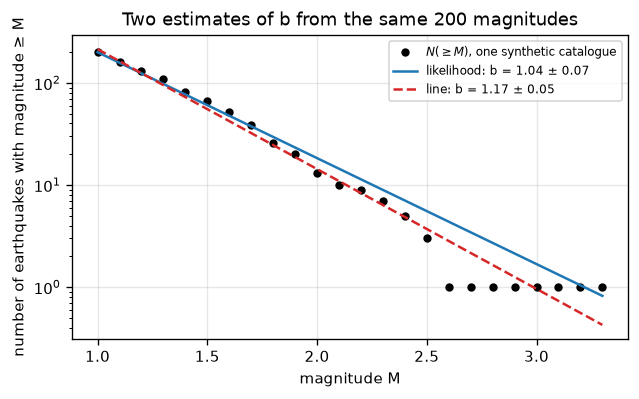

In [29]:
def b_likelihood(mags, mc):
    """Maximum-likelihood b-value of the magnitudes at or above mc: (b, standard error, count)."""
    x = mags[mags >= mc] - mc
    b = 1 / (np.log(10) * x.mean())
    return b, b / np.sqrt(len(x)), len(x)


def b_line(mags, mc, step=0.1):
    """The shortcut: a least-squares line through log10 N(>= M), with the standard error that fit reports."""
    m = mags[mags >= mc]
    edges = np.arange(mc, m.max(), step)
    log_n = np.log10([(m >= e).sum() for e in edges])
    G = np.column_stack([np.ones(len(edges)), edges])
    coef = np.linalg.lstsq(G, log_n, rcond=None)[0]
    r = log_n - G @ coef
    cov = (r @ r) / (len(edges) - 2) * np.linalg.inv(G.T @ G)
    return -coef[1], np.sqrt(cov[1, 1]), len(m)


# One synthetic catalogue: 200 magnitudes above Mc = 1 from the law with b = 1.
B_TRUE, MC = 1.0, 1.0
one = MC + np.random.default_rng(5).exponential(1 / (B_TRUE * np.log(10)), 200)
b_l, se_l, _ = b_likelihood(one, MC)
b_s, se_s, _ = b_line(one, MC)
print(f"truth b = {B_TRUE}")
print(f"likelihood:  b = {b_l:.3f} +/- {se_l:.3f}   misses the truth by {abs(b_l - B_TRUE) / se_l:.1f} of its standard errors")
print(f"line:        b = {b_s:.3f} +/- {se_s:.3f}   misses the truth by {abs(b_s - B_TRUE) / se_s:.1f} of its standard errors")

edges = np.arange(MC, one.max(), 0.1)
fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.semilogy(edges, [(one >= e).sum() for e in edges], "ko", ms=4, label=r"$N(\geq M)$, one synthetic catalogue")
ax.semilogy(edges, len(one) * 10 ** (-b_l * (edges - MC)), "C0-", label=f"likelihood: b = {b_l:.2f} ± {se_l:.2f}")
coef_line = np.polyfit(edges, np.log10([(one >= e).sum() for e in edges]), 1)
ax.semilogy(edges, 10 ** np.polyval(coef_line, edges), "C3--", label=f"line: b = {b_s:.2f} ± {se_s:.2f}")
ax.set(xlabel="magnitude M", ylabel="number of earthquakes with magnitude ≥ M",
       title="Two estimates of b from the same 200 magnitudes")
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()


On this catalogue the line reports the smaller error bar, yet misses the truth by more than three of
its own standard errors. One catalogue could be bad luck. Whether an error bar tells the truth is a
question about repeated experiments, the test of A.3.

**Exercise 5.** Using `np.random.default_rng(4)`, generate 2,000 synthetic catalogues of 200
magnitudes above `MC` with `B_TRUE`, as in the cell above. Estimate $b$ in each with both
`b_likelihood` and `b_line`. For each estimator, store the fraction of catalogues whose interval
$\hat b \pm 1.96\,\mathrm{se}$ contains `B_TRUE` in the dict `cover`, and the standard deviation of
its 2,000 estimates in the dict `spread`, both keyed `"likelihood"` and `"line"`. Before running it,
predict which estimator's interval will contain the truth more often.


In [30]:
rep = np.random.default_rng(4)
estimates = {"likelihood": [], "line": []}
hits = {"likelihood": 0, "line": 0}
for _ in range(2000):
    mags = MC + rep.exponential(1 / (B_TRUE * np.log(10)), 200)
    for name, estimator in (("likelihood", b_likelihood), ("line", b_line)):
        b_est, se_est, _ = estimator(mags, MC)
        estimates[name].append(b_est)
        hits[name] += abs(b_est - B_TRUE) < 1.96 * se_est
cover = {name: hits[name] / 2000 for name in hits}
spread = {name: np.std(estimates[name]) for name in estimates}


In [31]:
# Check Exercise 5
if "cover" not in globals() or "spread" not in globals():
    print("Exercise 5 has not stored cover and spread yet")
else:
    for name in ("likelihood", "line"):
        print(f"{name:>10s}: interval contains the truth in {100 * cover[name]:4.1f} % of catalogues; "
              f"the estimates scatter by {spread[name]:.3f}")
    assert all(0 <= cover[k] <= 1 for k in cover), "store fractions between 0 and 1, not counts"
    assert 0.93 < cover["likelihood"] < 0.98, \
        "the likelihood interval should contain the truth about 95 % of the time: is it b +/- 1.96 se?"
    assert cover["line"] < 0.6 and spread["line"] > 1.5 * spread["likelihood"], \
        "estimate b with b_likelihood and with b_line on the same catalogue, each with its own 1.96-se interval"


likelihood: interval contains the truth in 94.8 % of catalogues; the estimates scatter by 0.071
      line: interval contains the truth in 25.1 % of catalogues; the estimates scatter by 0.174


The likelihood's interval contains the truth 95 % of the time, as an honest error bar should. The
line's interval contains it in only about a quarter of the catalogues, although its estimates
scatter more than twice as much. The line is not only a noisier estimate: the error bar it reports
is wrong, because the assumptions that error bar rests on are broken.


## Part B · Application: the *b*-value of The Geysers

### B.1 · The catalogue, and where to cut it

Now the two estimators of A.7 on real data: earthquakes in the producing field of The Geysers (the
window `FIELD` of `geysers_data.py`) from 2021 to 2025. There is no true $b$ to compare with here.
Project question 3 asks whether $b$ changes with injection in this field.

Real catalogues add a problem the synthetic magnitudes did not have. A catalogue holds only the
earthquakes its network detected, and below the **magnitude of completeness** the network misses
events, so the counts fall short of the law (project notebook § 9). The estimate must start at a cut
above it.


In [32]:
import importlib.util
import sys
import time
import urllib.request

# The course's data module. On DataHub it sits beside the notebook; Colab opens the notebook alone,
# so there it is fetched.
BASE = "https://raw.githubusercontent.com/AI4EPS/EPS207_Observational_Seismology/main/docs/notebooks"
if "google.colab" in sys.modules or importlib.util.find_spec("geysers_data") is None:
    for attempt in range(4):
        try:
            urllib.request.urlretrieve(f"{BASE}/geysers_data.py", "geysers_data.py")
            break
        except Exception as exc:
            if attempt == 3:
                raise RuntimeError(f"could not fetch geysers_data.py: {exc}; re-run this cell") from None
            time.sleep(2 * (attempt + 1))
from geysers_data import catalog, FIELD

cat = catalog()                                   # the NCEDC routine catalogue, earthquakes only
field = cat[cat.longitude.between(FIELD[0], FIELD[1]) & cat.latitude.between(FIELD[2], FIELD[3])
            & cat.year.between(2021, 2025)]
mags = field.mag.to_numpy()
print(f"{len(field):,} earthquakes in the field window, 2021-2025, M {mags.min():.2f} to {mags.max():.2f}")
print("magnitude types:", field.magType.value_counts().to_dict(), "  (d = coda duration)")
print(f"magnitudes that are whole multiples of 0.01: {np.mean(np.isclose(mags * 100, np.round(mags * 100))):.1%}")
values, counts = np.unique(np.round(mags, 2), return_counts=True)
top = np.argsort(counts)[::-1][:4]
print("most often reported values:", ", ".join(f"M {values[i]:.2f} ({counts[i]:,} times)" for i in top))


88,416 earthquakes in the field window, 2021-2025, M -0.74 to 4.65
magnitude types: {'d': 88313, 'l': 48, 'w': 28, 'h': 27}   (d = coda duration)
magnitudes that are whole multiples of 0.01: 100.0%
most often reported values: M 0.85 (3,305 times), M 0.36 (2,869 times), M 0.76 (2,215 times), M 0.35 (1,858 times)


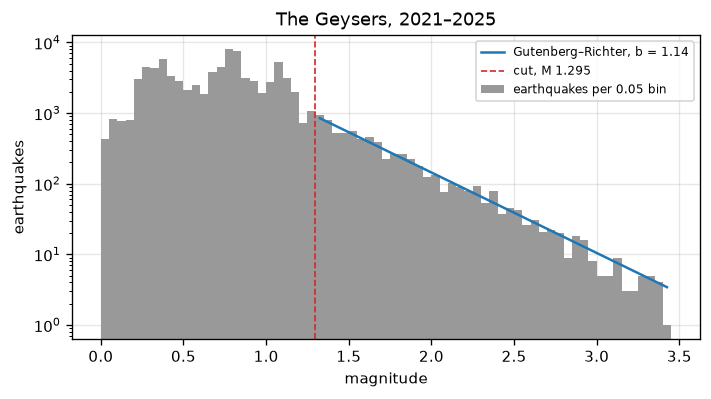

In [33]:
bins = np.arange(0.0, 3.5, 0.05)
counts_per_bin = np.histogram(mags, bins=bins)[0]
CUT = 1.295
b_geysers, se_geysers, n_geysers = b_likelihood(mags, CUT)
law = n_geysers * (np.exp(-b_geysers * np.log(10) * (bins[:-1] - CUT))
                   - np.exp(-b_geysers * np.log(10) * (bins[1:] - CUT)))

fig, ax = plt.subplots(figsize=(6.0, 3.4))
ax.bar(bins[:-1], counts_per_bin, width=0.05, align="edge", color="0.6", label="earthquakes per 0.05 bin")
above = bins[:-1] >= CUT
ax.plot(bins[:-1][above] + 0.025, law[above], "C0-", lw=1.5, label=f"Gutenberg–Richter, b = {b_geysers:.2f}")
ax.axvline(CUT, color="C3", lw=1, ls="--", label="cut, M 1.295")
ax.set_yscale("log")
ax.set(xlabel="magnitude", ylabel="earthquakes", title="The Geysers, 2021–2025")
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()


Below about M 1.2 the counts jump between neighbouring bins, and single values are reported
thousands of times. The sizes of earthquakes vary continuously, so this unevenness comes from how
the magnitudes are computed and reported, not from the earthquakes. Above M 1.3 the counts follow the
law's straight line, with some unevenness from bin to bin.

The cut sits at 1.295 rather than 1.3 for a precise reason. Magnitudes are reported to 0.01, so a
reported 1.30 stands for anything from 1.295 to 1.305, and $M_c$ in the estimator is the lower edge
of that interval. This is Utsu's correction for magnitudes reported in steps (reviewed by Marzocchi
& Sandri, 2003). Using 1.30 instead would shift $b$ by about one standard error.

### B.2 · The estimate, and how much it depends on the cut

Two checks follow: how $\hat b$ changes as the cut moves, and how both estimators behave on synthetic
catalogues the size of this one.


cut at 1.295: likelihood b = 1.140 +/- 0.014 (6,973 earthquakes)
              line       b = 1.071 +/- 0.022
cut at 1.300: likelihood b = 1.155  (shift +0.015)
b at 1.295 lies inside the 95 % interval of 12 of the 12 cuts from 1.195 up

300 synthetic catalogues of 6,973 magnitudes with b = 1.140:
  likelihood estimates scatter by 0.014
  line estimates scatter by 0.098 and average 1.116; that scatter is 4.5 times the error bar the line reported


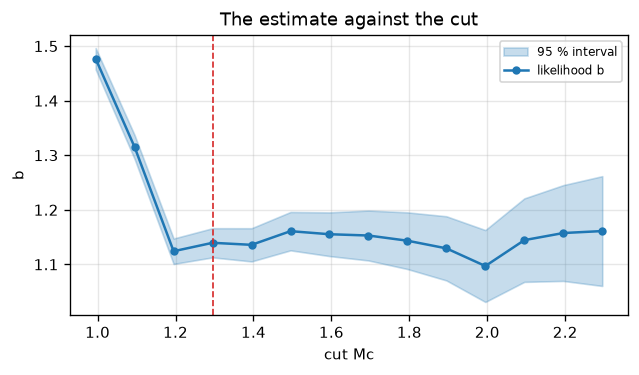

In [34]:
cuts = np.arange(0.995, 2.35, 0.1)
by_cut = np.array([b_likelihood(mags, c)[:2] for c in cuts])
b_130 = b_likelihood(mags, 1.30)[0]
b_s, se_s, _ = b_line(mags, CUT)

rep = np.random.default_rng(6)
sims = np.array([[b_likelihood(m_, CUT)[0], b_line(m_, CUT)[0]]
                 for m_ in (CUT + rep.exponential(1 / (b_geysers * np.log(10)), n_geysers) for _ in range(300))])

print(f"cut at 1.295: likelihood b = {b_geysers:.3f} +/- {se_geysers:.3f} ({n_geysers:,} earthquakes)")
print(f"              line       b = {b_s:.3f} +/- {se_s:.3f}")
print(f"cut at 1.300: likelihood b = {b_130:.3f}  (shift {b_130 - b_geysers:+.3f})")
inside = [abs(b_geysers - b_c) < 1.96 * se_c for c, (b_c, se_c) in zip(cuts, by_cut) if c >= 1.19]
print(f"b at 1.295 lies inside the 95 % interval of {sum(inside)} of the {len(inside)} cuts from 1.195 up")
print(f"\n300 synthetic catalogues of {n_geysers:,} magnitudes with b = {b_geysers:.3f}:")
print(f"  likelihood estimates scatter by {sims[:, 0].std():.3f}")
print(f"  line estimates scatter by {sims[:, 1].std():.3f} and average {sims[:, 1].mean():.3f}; "
      f"that scatter is {sims[:, 1].std() / se_s:.1f} times the error bar the line reported")

fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.fill_between(cuts, by_cut[:, 0] - 1.96 * by_cut[:, 1], by_cut[:, 0] + 1.96 * by_cut[:, 1], color="C0", alpha=0.25,
                label="95 % interval")
ax.plot(cuts, by_cut[:, 0], "C0o-", ms=4, label="likelihood b")
ax.axvline(CUT, color="C3", lw=1, ls="--")
ax.set(xlabel="cut Mc", ylabel="b", title="The estimate against the cut")
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()


Below the step at M 1.2 the estimate climbs steeply, which is the unevenness of the reported
magnitudes. From a cut of 1.2 upwards, the value at 1.295 lies inside every cut's 95 % interval, so the
*b*-value of these coda-duration magnitudes does not hinge on the exact cut: $b = 1.14 \pm 0.014$.

The line gives a smaller $b$ with an error bar of about $\pm 0.02$. The synthetic catalogues show
that at this size the line's estimates scatter by about 0.1, so its disagreement with the
likelihood is expected, and the error bar it reports is several times too small.


### B.3 · Testing the error bar without the truth

The likelihood says $b$ is known to $\pm 0.014$. There is no true value to compare with, but the
claim can still be tested by repetition, using the data themselves. Split the earthquakes into two
halves at random, many times. Each half has half the earthquakes, so each half's standard error is
larger by $\sqrt 2$, and the difference between two halves should scatter by
$\sqrt 2 \times \sqrt 2 \times 0.014 = 2 \times 0.014$. Then split the earthquakes by time instead:
the first half against the second.


In [35]:
rep = np.random.default_rng(7)
random_differences = []
for _ in range(300):
    half = rep.random(len(mags)) < 0.5
    random_differences.append(b_likelihood(mags[half], CUT)[0] - b_likelihood(mags[~half], CUT)[0])
print(f"random halves: differences scatter by {np.std(random_differences):.3f}; "
      f"the error bar predicts {2 * se_geysers:.3f}")

ordered = field.sort_values("time")
early = ordered.mag.to_numpy()[: len(ordered) // 2]
late = ordered.mag.to_numpy()[len(ordered) // 2:]
b_early, se_early, _ = b_likelihood(early, CUT)
b_late, se_late, _ = b_likelihood(late, CUT)
gap = (b_late - b_early) / np.hypot(se_early, se_late)
split_date = ordered.time.iloc[len(ordered) // 2]
print(f"\nby time, split on {split_date:%Y-%m-%d}: b = {b_early:.3f} +/- {se_early:.3f} before, "
      f"{b_late:.3f} +/- {se_late:.3f} after; difference {gap:.1f} standard errors")

print("\nyear   b       std error")
for year, year_events in field.groupby("year"):
    b_y, se_y, _ = b_likelihood(year_events.mag.to_numpy(), CUT)
    print(f"{year}   {b_y:.3f}   {se_y:.3f}")


random halves: differences scatter by 0.029; the error bar predicts 0.027

by time, split on 2023-09-20: b = 1.041 +/- 0.019 before, 1.229 +/- 0.020 after; difference 6.9 standard errors

year   b       std error
2021   1.032   0.032
2022   1.041   0.032
2023   1.080   0.030
2024   1.220   0.030
2025   1.249   0.028


Random halves differ by close to what the error bar predicts, so $\pm 0.014$ is a fair statement of
the sampling error. The two halves in time differ by almost seven standard errors, and the yearly
values show when: $b$ is 1.03–1.08 in 2021–2023 and 1.22–1.25 in 2024–2025. A single $b$ with
$\pm 0.014$ does not describe this period.

Something changed between the halves: the earthquakes (their sizes, or where in the field they
occur), or the way their magnitudes were measured. This notebook cannot tell which. A change of $b$
over time is not unusual here: Trugman et al. (2016) report significant temporal variations in the
Gutenberg–Richter $b$-value in California's largest geothermal fields, The Geysers among them.
Deciding what drives this change is the work of project question 3.


## Takeaways

### Machine learning

- A model that is linear in its parameters is a design matrix. Least squares solves it through the
  normal equations and leaves a residual orthogonal to every column.
- $R^2$ never falls when a column is added, even a column of noise, and it says nothing about how well
  any coefficient is determined.
- Least squares is the maximum-likelihood estimate for independent Gaussian errors. The same
  recipe (likelihood, maximum, curvature) gives an estimate and its error bar for other data, such as
  the exponential magnitudes of A.7.
- An error bar is a claim about repeated experiments, and repeating them tests it: the least-squares
  intervals of A.3 contained the truth 95 % of the time, and the line through cumulative counts in
  A.7 reported an interval that contained it in only about a quarter of catalogues.
- A confidence interval describes the fitted curve and shrinks with more data. A prediction interval
  describes the next measurement and cannot shrink below the scatter of the data.
- Correlated columns leave a combination of coefficients well determined and the individual coefficients
  poorly determined, and centring the columns does not change that.
- Ridge regression is the MAP estimate under a Gaussian prior, with $\lambda = \sigma^2/s^2$. It shrinks the
  directions the data constrain least, it pays when parameters rest on few data, and cross-validation
  chooses its $\lambda$ without knowing the truth.


### Seismology

- A magnitude is a distance-corrected log amplitude. Richter (1935) defined it by the amplitude a
  standard seismometer would record at 100 km, and Hutton & Boore (1987) fitted the distance
  correction for southern California from 7,355 amplitudes of 814 earthquakes.
- Above the magnitude of completeness, magnitudes follow the Gutenberg–Richter law, so they are
  exponentially distributed and $b$ follows from their mean (Aki, 1965; Marzocchi & Sandri, 2003).
- At The Geysers in 2021–2025, the *b*-value of the catalogue's coda-duration magnitudes above M 1.3 is
  about 1.14, but the first and second halves of the period differ by far more than sampling error
  allows, consistent with the temporal variations in $b$ that Trugman et al. (2016) report there.

### References

- Aki, K. (1965). Maximum likelihood estimate of *b* in the formula log *N* = *a* − *bM* and its
  confidence limits. *Bulletin of the Earthquake Research Institute, University of Tokyo*, 43, 237–239.
- Gutenberg, B., & Richter, C. F. (1954). *Seismicity of the Earth and Associated Phenomena* (2nd ed.).
  Princeton University Press.
- Hutton, L. K., & Boore, D. M. (1987). The *M*L scale in southern California. *BSSA*, 77(6),
  2074–2094. https://doi.org/10.1785/BSSA0770062074
- Marzocchi, W., & Sandri, L. (2003). A review and new insights on the estimation of the *b*-value and
  its uncertainty. *Annals of Geophysics*, 46(6), 1271–1282. https://doi.org/10.4401/ag-3472
- Richter, C. F. (1935). An instrumental earthquake magnitude scale. *BSSA*, 25(1), 1–32.
  https://doi.org/10.1785/BSSA0250010001
- Trugman, D. T., Shearer, P. M., Borsa, A. A., & Fialko, Y. (2016). A comparison of long-term changes in
  seismicity at The Geysers, Salton Sea, and Coso geothermal fields. *JGR: Solid Earth*, 121, 225-247.
  https://doi.org/10.1002/2015JB012510